# Fig: phi (dict elements)

project = ```iP-VAE```, host = ```mach```, device = ```cuda:3```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Results & Figs dir

In [3]:
pal_models = get_palette_models()

chkpts_dir = add_home('Dropbox/chkpts/_IterativeVAE')
figs_dir = pjoin(fig_base_dir, 'figs_2025-03', 'phi')
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(chkpts_dir)), len(os.listdir(figs_dir))

(663, 9)

## Selected fits

In [4]:
selected_fits = [
    'poisson_<grad|lin>_vH16-wht_t-16_b-24_k-[512]_mach-0_(2025_05_13,12:46)',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-8_k-[512]_mach-0_(2025_05_13,12:47)',
    'gaussian_<grad|lin>_vH16-wht_t-16_b-8_k-[512]_mach-0_(2025_05_13,12:47)',
]

## Phi plots

100%|███████████████████████████████████| 3/3 [00:09<00:00,  3.19s/it]


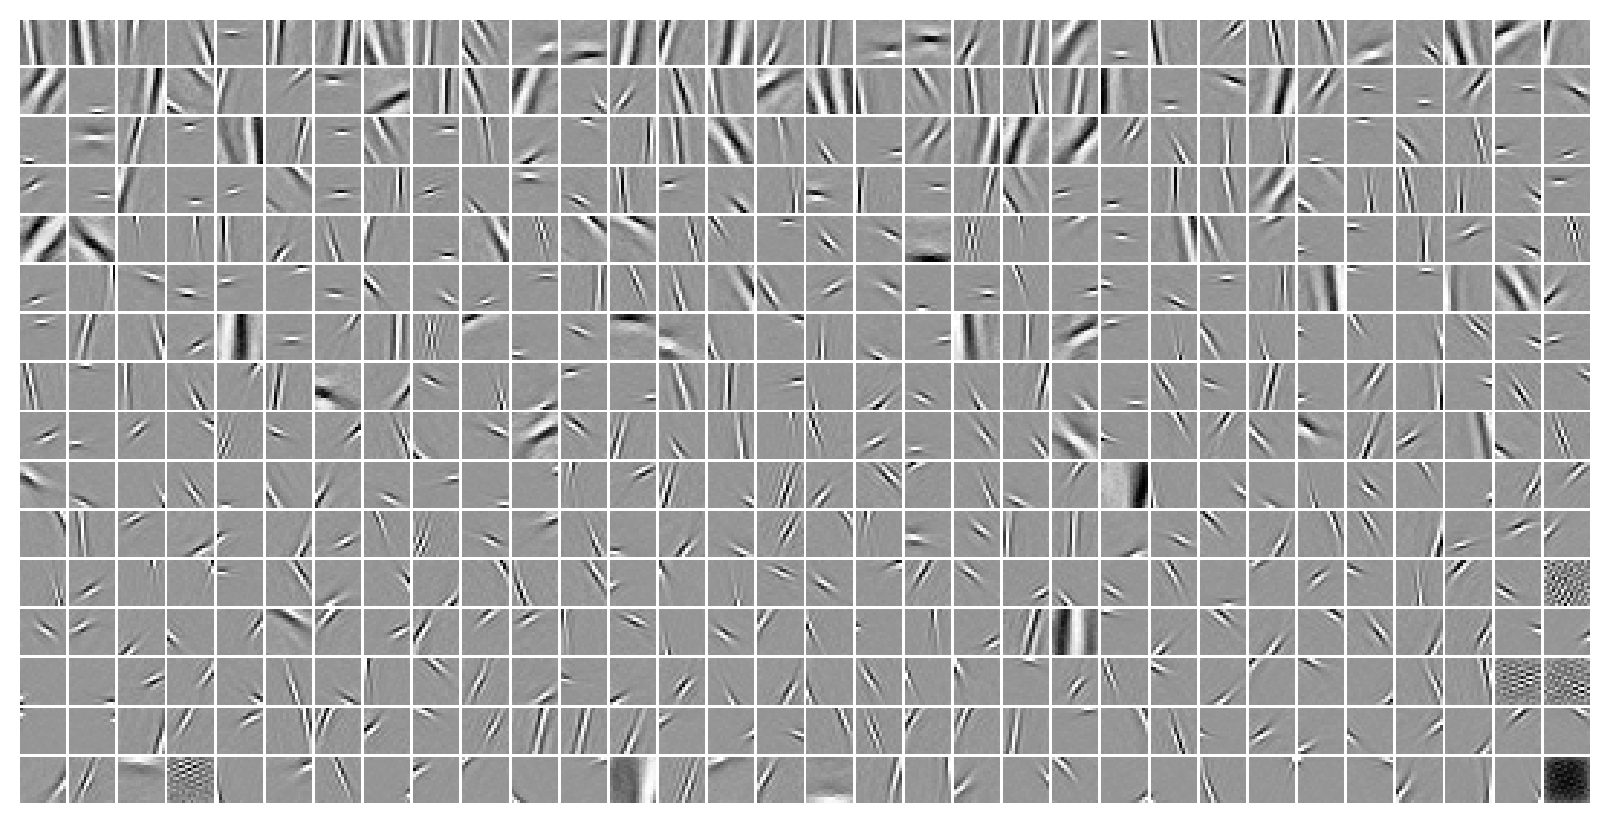

100%|███████████████████████████████████| 3/3 [00:07<00:00,  2.43s/it]


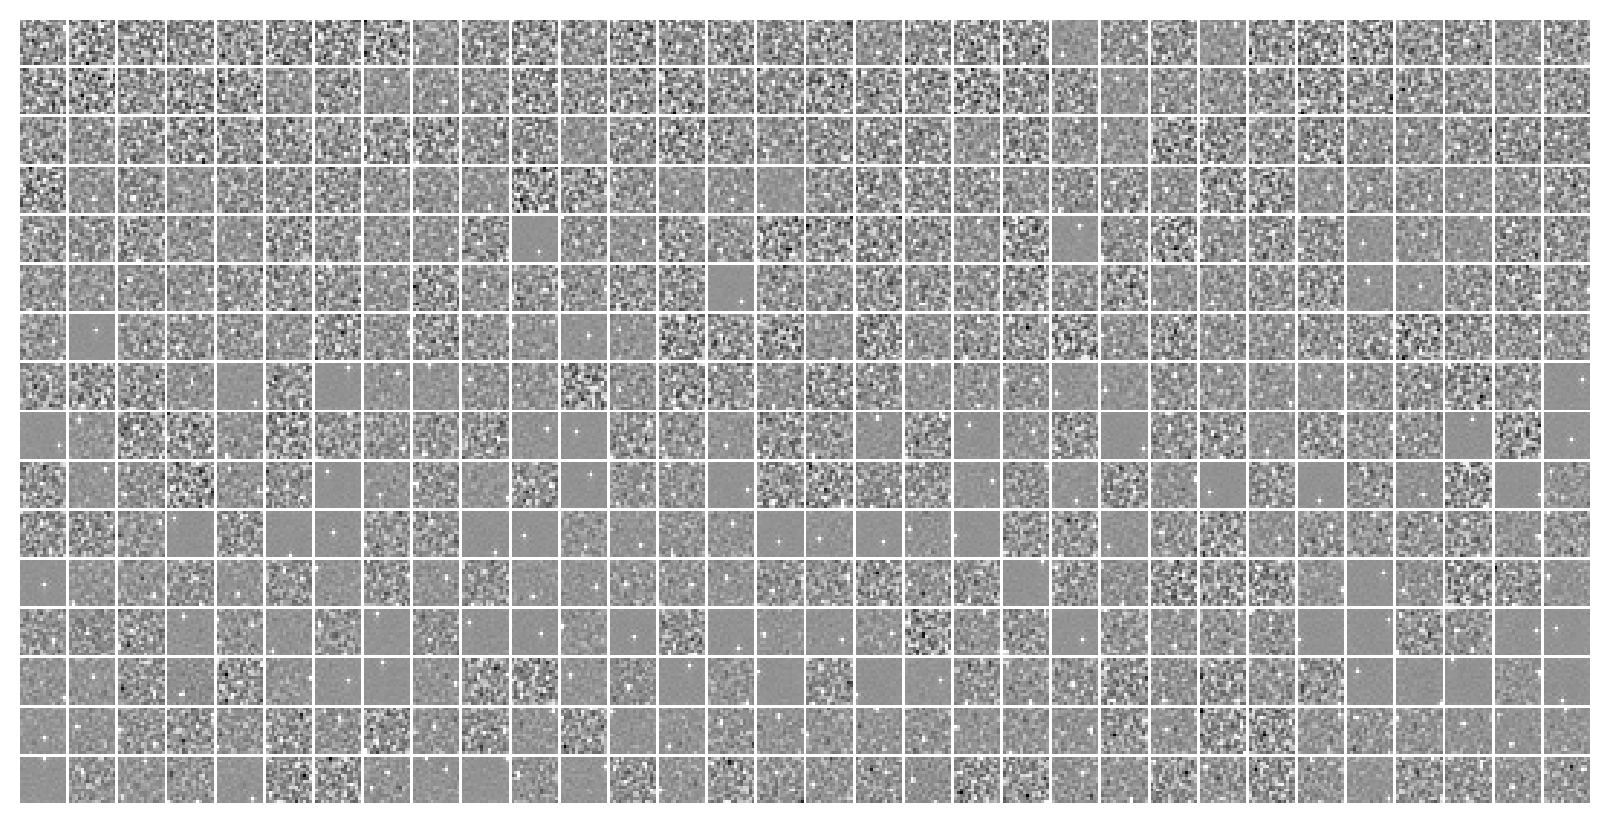

100%|███████████████████████████████████| 3/3 [00:07<00:00,  2.37s/it]


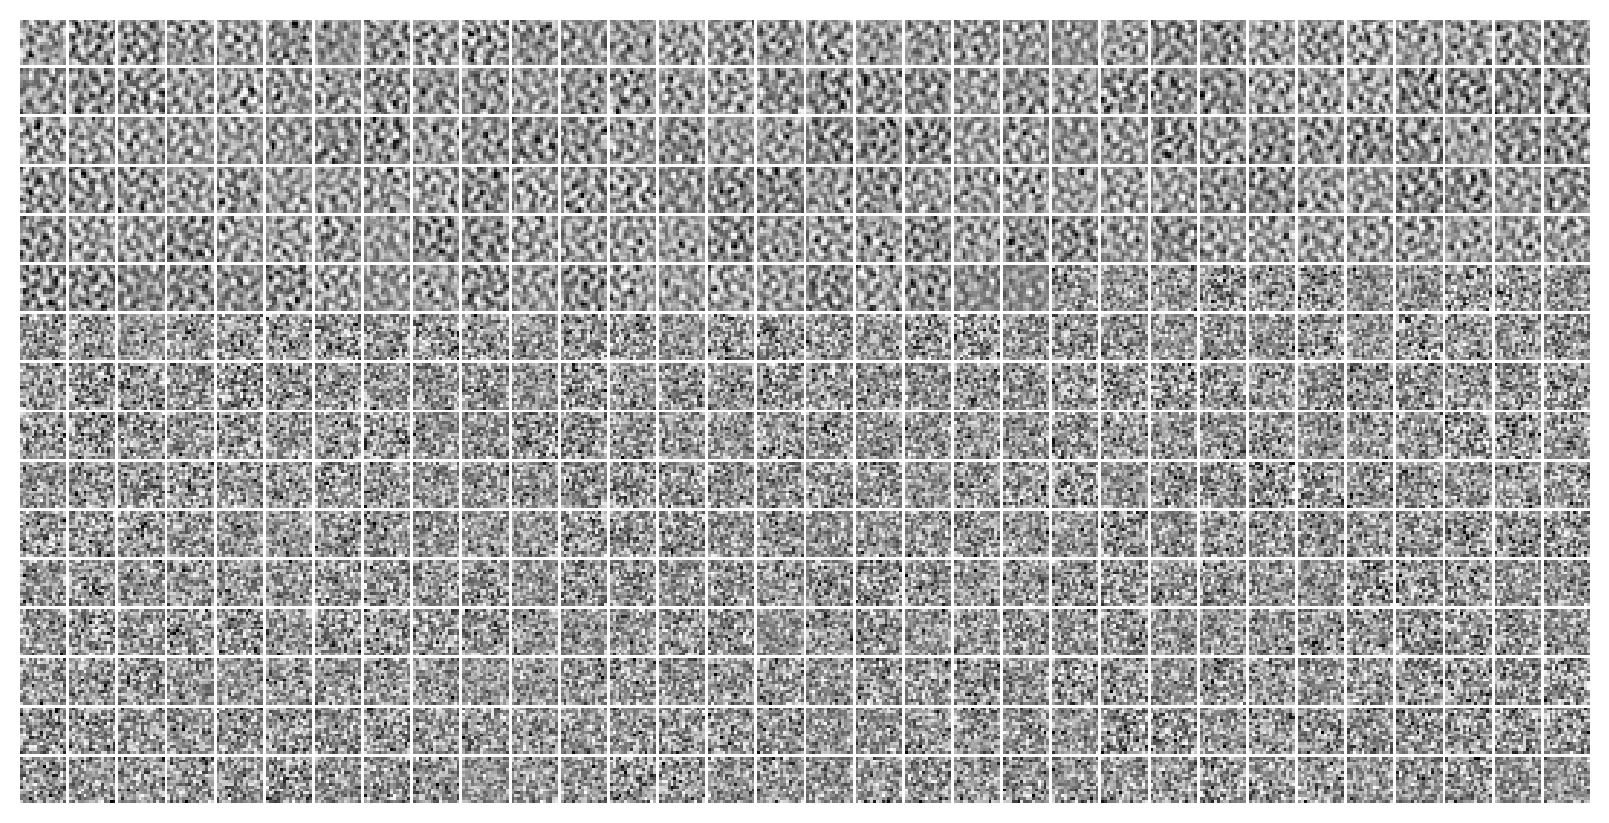

In [5]:
u_final_all = {}

for f in selected_fits:
    tr = load_model_lite(pjoin(chkpts_dir, f), device=device)[0]
    # u0 = tonp(tr.model.layer.u_init[0].squeeze())
    output = tr.xtract_ftr(data_batch_sz=9_000, n_data_batches=-1)
    u_final = output['state'][:, -1].mean(0)
    u_final_all[tr.model.cfg.str_model] = u_final
    order = np.argsort(u_final)
    fig, _ = tr.model.show(order=order, method='abs-max')
    # save
    model_str = f.split('_')[0].split('-')[0]
    fname = f"phi_{model_str}.png"
    save_fig(fname, figs_dir, fig)

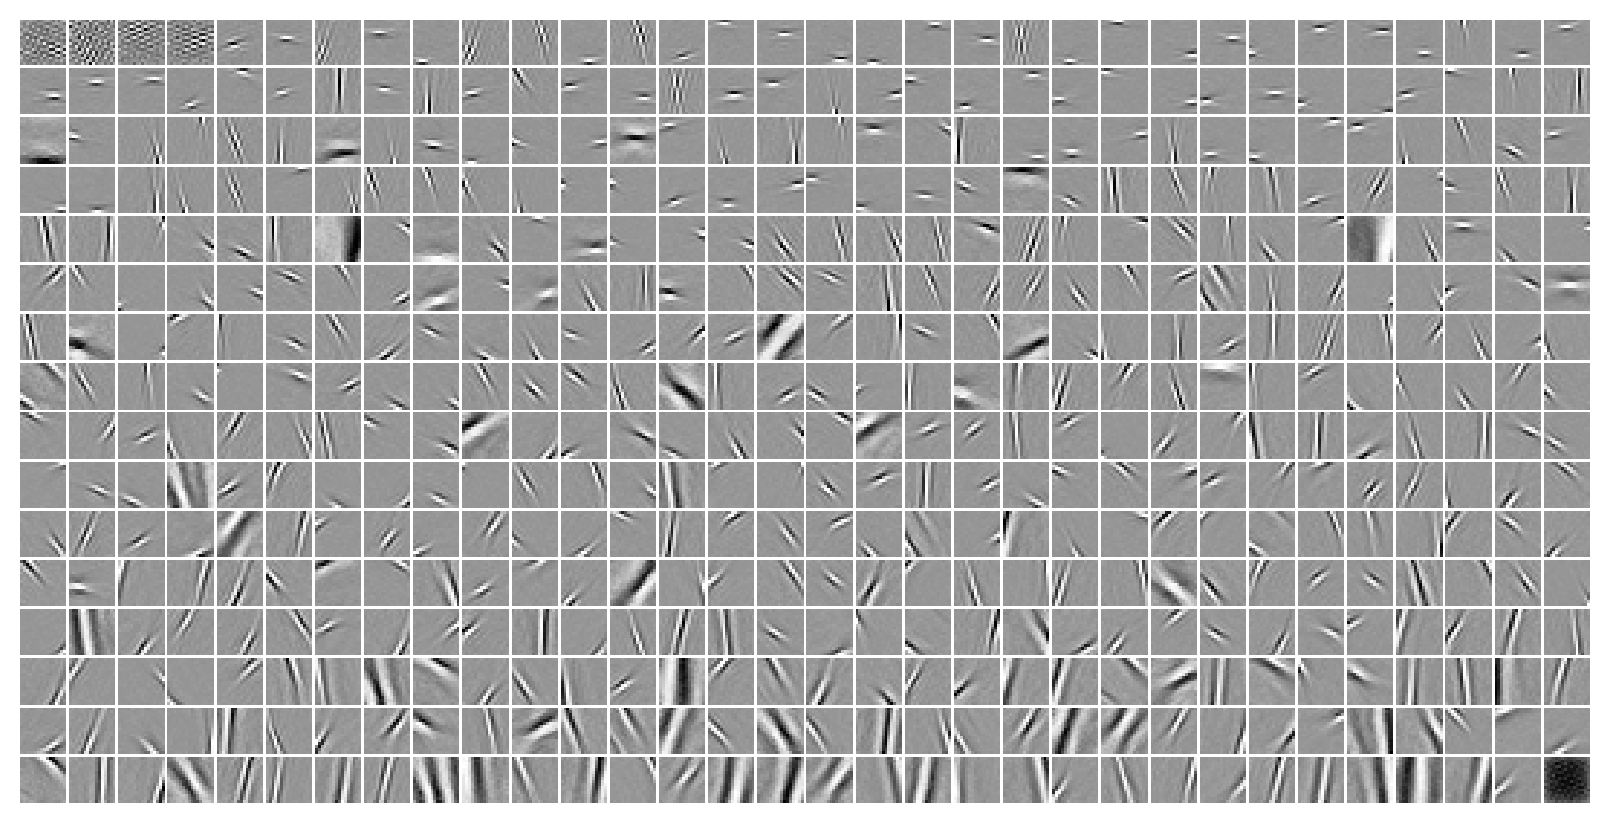

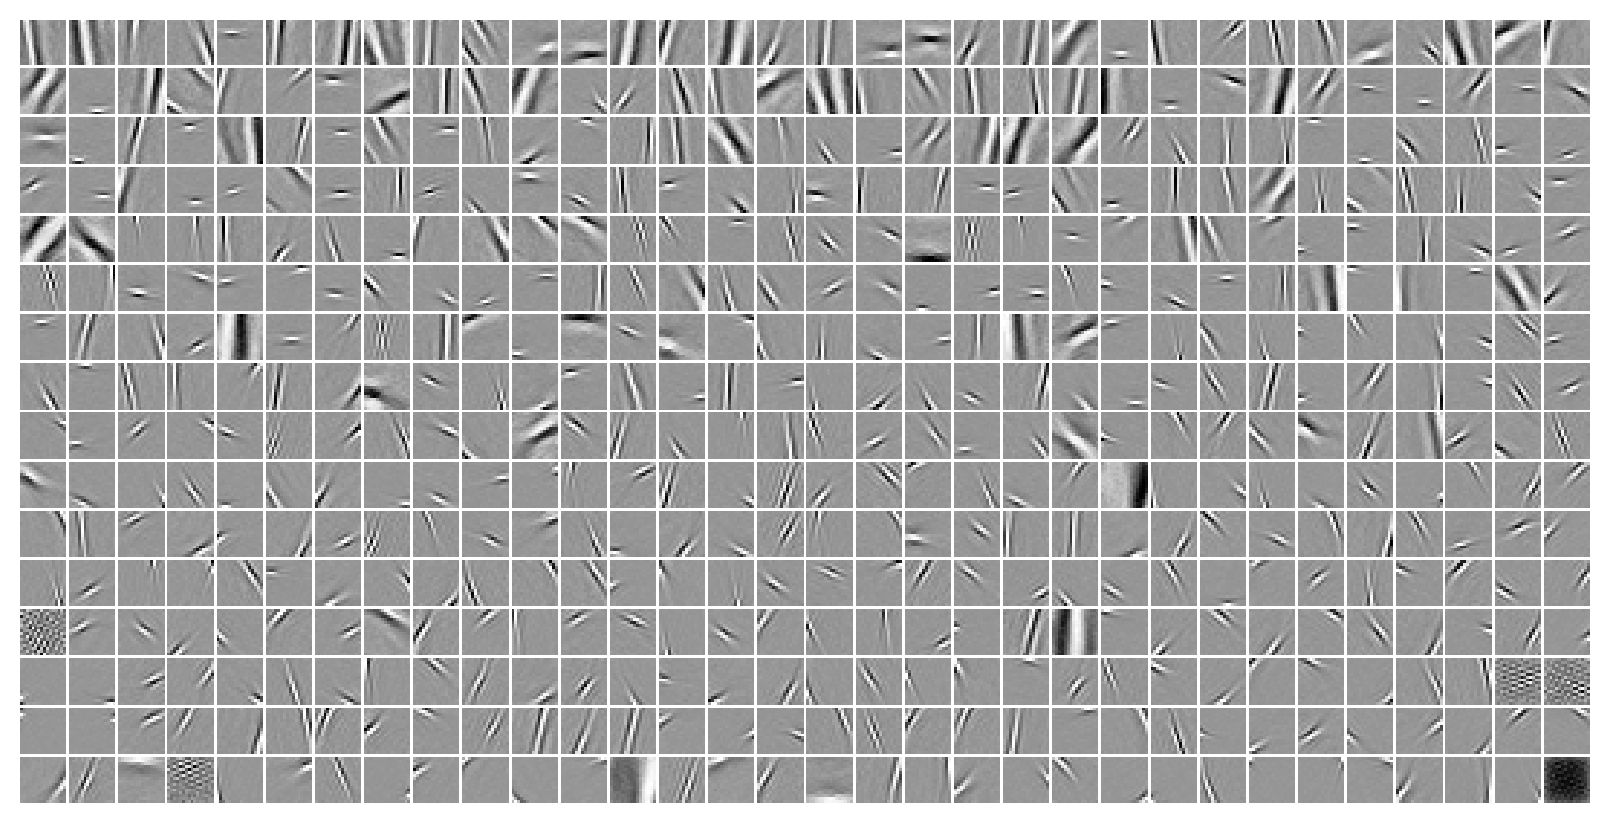

In [13]:
fig, _ = tr.model.show(order=np.argsort(u0), method='abs-max')
fig, _ = tr.model.show(order=np.argsort(u_final), method='abs-max')

## u final analysis

In [6]:
list(u_final_all)

['poisson', 'gaussian+relu', 'gaussian']

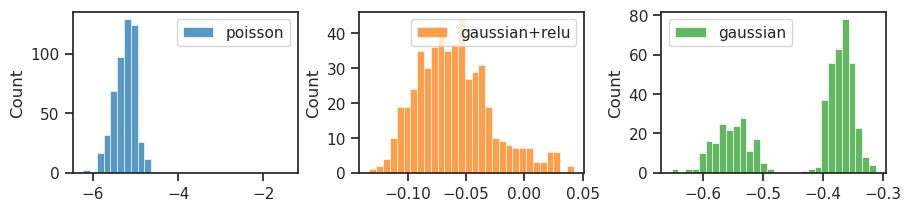

In [14]:
fig, axes = create_figure(1, len(u_final_all))
for i, (name, x2p) in enumerate(u_final_all.items()):
    sns.histplot(x2p, label=name, bins=30, color=f"C{i}", ax=axes[i])
add_legend(axes)
plt.show()

### 5 randomly selected projective fields

In [6]:
ids_dict = {
    'poisson': [380, 47, 281, 117, 338],
    'gaussian': range(70, 75),
    'gaussian+relu': [36, 261, 47, 155, 130], 
}

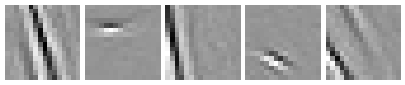

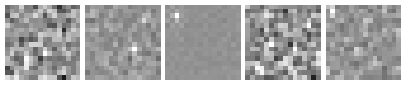

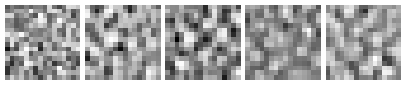

In [7]:
for f in selected_fits:
    # load
    tr = load_model_lite(pjoin(chkpts_dir, f))[0]
    u0 = tonp(tr.model.layer.u_init[0].squeeze())
    order = np.argsort(u0)
    # get ids
    model_str = f.split('_')[0].split('-')[0]
    ids = list(ids_dict[model_str])
    # make fig
    fig, _ = tr.model.show(order=order[ids], method='abs-max', nrows=1, dpi=50)
    # save
    fname = f"phi_{model_str}_{str(ids).replace(' ', '')}.png"
    # save_fig(fname, figs_dir, fig)